# **Project: Stock Price Prediction**

**Objective**: Predict the future stock price of Apple Inc. based on its current closing price.

# **Algorithm Used**: Long Short-Term Memory (LSTM)

## ***Methodology***: Predict the stock market closing price (the last price at which a financial security is traded during a trading session) of Apple Inc. using the closing prices from the previous 60 days.

Note: pandas-datareader is a common tool for fetching financial/economic data, but in this notebook the actual download is done with yfinance (see below).

In [ ]:
!pip install --upgrade pandas-datareader

In [ ]:
import numpy as np
import math
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
from datetime import datetime
import pandas_datareader.data as web
import yfinance as yf

# **Download the historical stock price data of Apple Inc. (AAPL) from Yahoo Finance.

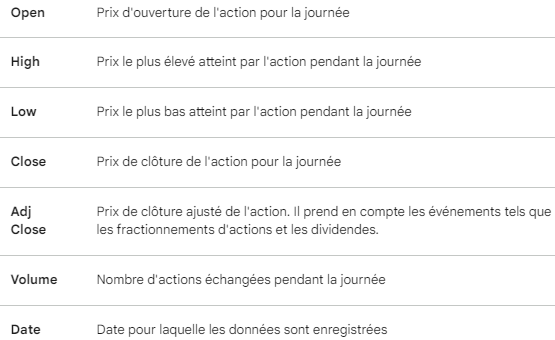

In [ ]:
# Get APPLE INC. stock market data using the ticker symbol AAPL from January 2012 to October 25, 2020.

# Download Apple stock price data (ticker symbol "AAPL") between the specified start and end dates
# using yfinance (a Python library/API for Yahoo Finance).
start = datetime(2012, 1, 12)
end = datetime(2020, 10, 25)
df = yf.download('AAPL', start=start, end=end)
df.head()

In [ ]:

df.shape

# Display the historical closing prices of Apple Inc..

# ** Data training**

In [ ]:
# Create a new DataFrame `data` by filtering `df` to keep only the "Close" column.
# filter(): pandas method to select columns matching specific conditions
data = df.filter(['Close'])

#dataframe to numpy array
dataset = data.values

# Compute the length of the training set (80% of the total data).
# math.ceil() rounds len(dataset) * 0.8 up to the nearest integer.
training_data_len = math.ceil(len(dataset)*.80)

In [ ]:
dataset.shape

Scale the numeric **data** to a common range. This step matters before training because different features (columns) can have different scales, which would affect the learning process.

In [ ]:
# Data Normalizing
# Normalize the data to the [0, 1] range
scaler = MinMaxScaler(feature_range=(0,1)) # create a MinMaxScaler `scaler` with range [0, 1]
scaled_data = scaler.fit_transform(dataset) # perform the actual normalization

In [ ]:
# extract the training set from the normalized data
# select all rows of scaled_data from index 0 up to (but not including) training_data_len
train_data = scaled_data[0:training_data_len]
print(train_data.shape)
# Split the data into input and output dataset (x_train, y_train)
x_train = []
y_train = []

# build the scaled training set by extracting sequences of 60 consecutive days of normalized closing prices
# 60 is coming form 60 days.
for i in range(60, len(train_data)):
    x_train.append(train_data[i-60: i]) # x: an input sequence of 60 consecutive values; column 0 is the normalized closing price
    y_train.append(train_data[i]) # y: the current (60th-day) closing price

In [ ]:
print(len(x_train))
print(len(y_train))

In [ ]:
# Convert x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

Long Short-Term Memory (LSTM) networks need 3-dimensional input data to capture temporal relationships across sequences.

In [ ]:
# reshape data into 3D form (num samples, num timesteps, num features) - the shape accepted by LSTM
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# dim1: number of samples (sequences),
# dim2: number of timesteps (days) per sequence,
# dim3: extra dimension of size 1 for the number of features (normalized closing price)

In [ ]:
x_train.shape

# **Build the model**
* Build the LSTM model with two LSTM layers of 50 neurons and two Dense layers (one with 25 neurons, one with 1).

**units=50**: number of internal memory units in the LSTM layer. Here, 50 units are used.

**return_sequences=True**: tells the LSTM layer to return not only the final output but the outputs for every timestep. This lets the second LSTM layer access temporal information across the whole sequence.

**input_shape=(x_train.shape[1], 1):**  
*   **x_train.shape[1]**: number of timesteps (days) per sequence, read from x_train's shape.
*   **1**: number of features (normalized closing price) per timestep.

In [ ]:
# Build LSTM model
model=Sequential()
model.add(LSTM(units=50,return_sequences=True,input_shape=(x_train.shape[1],1))) # (60,1)
model.add(LSTM(units=50,return_sequences=False)) # return only the final output of the sequence
model.add(Dense(25)) # activation: linear (default)
model.add(Dense(1)) # Output neuron produces the normalized predicted closing price for the next timestep.

In [ ]:
#Compile the LSTM model
model.compile(optimizer='adam',loss='mean_squared_error') # Mean squared error (MSE) is used as the loss function.
# MSE = mean of squared differences between predictions and true values.

In [ ]:
# prompt: how to configure the eraly stopping configure

from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='loss', patience=100, mode='min', verbose=1)

history = model.fit(x_train, y_train, epochs=1000, batch_size=32, callbacks=[early_stopping])


# **Learning curves**

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training  Loss')
plt.legend()
plt.show()


# **Build the test set**

*   **training_data_len**: length of the training set (80% of the total dataset).
*   **-60**: step back 60 days so the test sequences overlap the end of the training set.
*   **:** selects all columns for the remaining rows in scaled_data.




In [ ]:
# Extract test data from the normalized dataset
test_data = scaled_data[training_data_len-60:]
x_test = []
y_test = dataset[training_data_len:]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i])

# Convert the x_test set to a numpy array
x_test = np.array(x_test)

# Reshape the data into 3-dimensional form (no of samples, no of time steps, no of features) the shape accepted by LSTM
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# **Model validation**

Predict prices and evaluate the model

In [ ]:
# Generate normalized closing-price predictions from the test input sequences (x_test).
prediction = model.predict(x_test)
print(len(prediction))
# Prices were normalized to [0, 1] before training.
# --> invert the normalization to bring predictions back to the original price scale.
# --> uses the min/max parameters from the original MinMaxScaler fit to undo the scaling.
prediction = scaler.inverse_transform(prediction)

# Compute root mean squared error (RMSE) to evaluate model performance.
# MSE measures the average difference between model predictions and the real test closing prices (y_test).
mse = np.sqrt( np.mean(prediction-y_test)**2)
print("MSE= ", mse)

# **Data tests**
* Model validation complete, with acceptable prediction accuracy.
Run the data tests.

In [ ]:
# Build and display the prediction chart
train=data[:training_data_len] # training set
valid=data[training_data_len:] # validation set
valid['Prediction']=prediction # add a new "Prediction" column to the validation set

# Visualise the data
plt.figure(figsize=(8,4))
plt.title('Stock Price Prediction Chart')
plt.xlabel('Date',fontsize=18)
plt.ylabel('Close Price (USD)',fontsize=18)
plt.plot(train['Close']) # plot the training-set closing-price curve
plt.plot(valid[['Close','Prediction']]) # plot two more curves: real closing prices and predicted closing prices on the validation set
plt.legend(['Train','Val','Prediction'],loc='lower right')
plt.show()

In [ ]:
# Show real (validation) and predicted prices
valid